# 02 Dimensions Analysis


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from numpy import linalg as la

from config import PROCESSED_DATAFRAMES_DIR


SV_DATAFRAME_PATH = PROCESSED_DATAFRAMES_DIR / "sv_qse_data.pkl"

df_sv = pd.read_pickle(SV_DATAFRAME_PATH)

df_sv.head()


,molecule,active_space,ansatz,expansion,H,S,qse_dim,S2,S_spin,pyscf_casci_energies
0,Acetamide,2e2o,1UpCCGSDSinglet,singlet,"[[(-802.5663414572622+0j), (-4.706692634862637...","[[(3.9097041888243123+0j), (0.0229245233142809...",4,"[[(1.27675647831893e-14+0j), (-4.3368086899420...","[[(3.9097041888243123+0j), (0.0229245233142809...","[-205.29449911826816, -204.8258180441669, -204..."
1,Acetamide,2e2o,1UpCCGSDSinglet,triplet,"[[(-0.008069881124952466+0j), (0.1930299587744...","[[(3.9350963402490224e-05+0j), (-0.00094126725...",4,"[[(7.870192680212162e-05+0j), (-0.001882534507...","[[(3.9350963402490224e-05+0j), (-0.00094126725...",[-205.07455054622517]
2,Acetamide,2e2o,UCCGSD,singlet,"[[(-802.5658955566977+0j), (-4.714686911530124...","[[(3.909702017207626+0j), (0.02296346038353209...",4,"[[(1.2961853812498703e-14+0j), (-4.33680868994...","[[(3.909702017207626+0j), (0.02296346038353209...","[-205.29449911826816, -204.8258180441669, -204..."
3,Acetamide,2e2o,UCCGSD,triplet,"[[(-0.00809733319789395+0j), (0.19335947310663...","[[(3.9484827272451284e-05+0j), (-0.00094287405...",4,"[[(7.896965454190497e-05+0j), (-0.001885748112...","[[(3.9484827272451284e-05+0j), (-0.00094287405...",[-205.07455054622517]
4,Acetamide,2e2o,UCCSD,singlet,"[[(-802.5658955566977+0j), (-4.714686911530124...","[[(3.909702017207626+0j), (0.02296346038353209...",4,"[[(1.2961853812498703e-14+0j), (-4.33680868994...","[[(3.909702017207626+0j), (0.02296346038353209...","[-205.29449911826816, -204.8258180441669, -204..."


## 1. Overlap Eigenvalue Edge Cases

Compare representative small and larger active spaces side by side, such as `2e3o` and `4e4o`, to show how the overlap-matrix spectrum changes with QSE dimension. The goal is to make the tiny-eigenvalue problem visible before applying any filtering or stabilization.



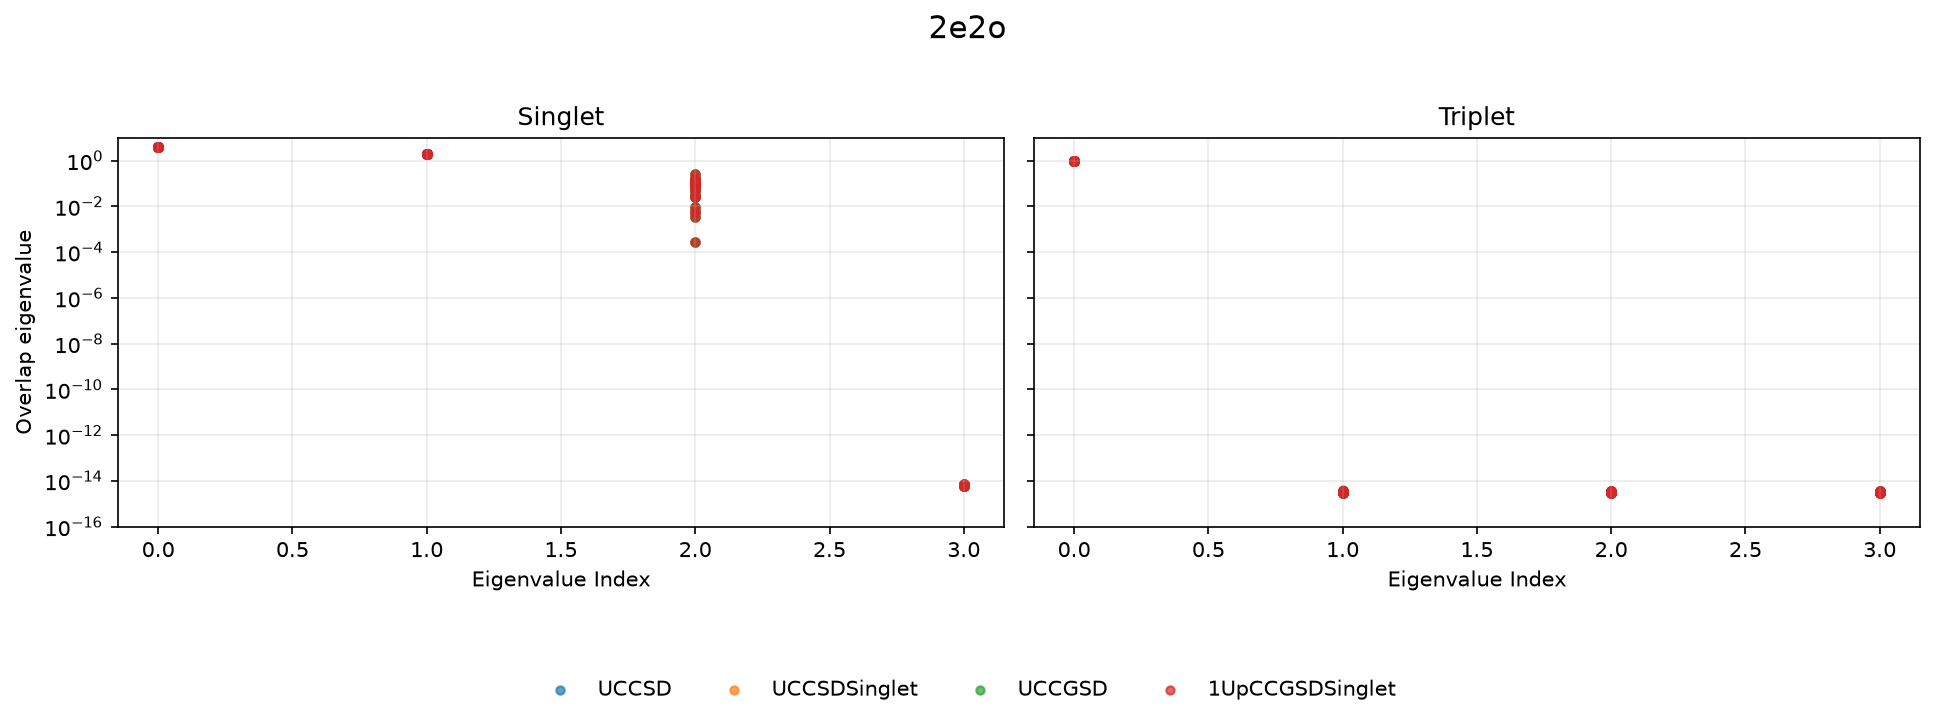
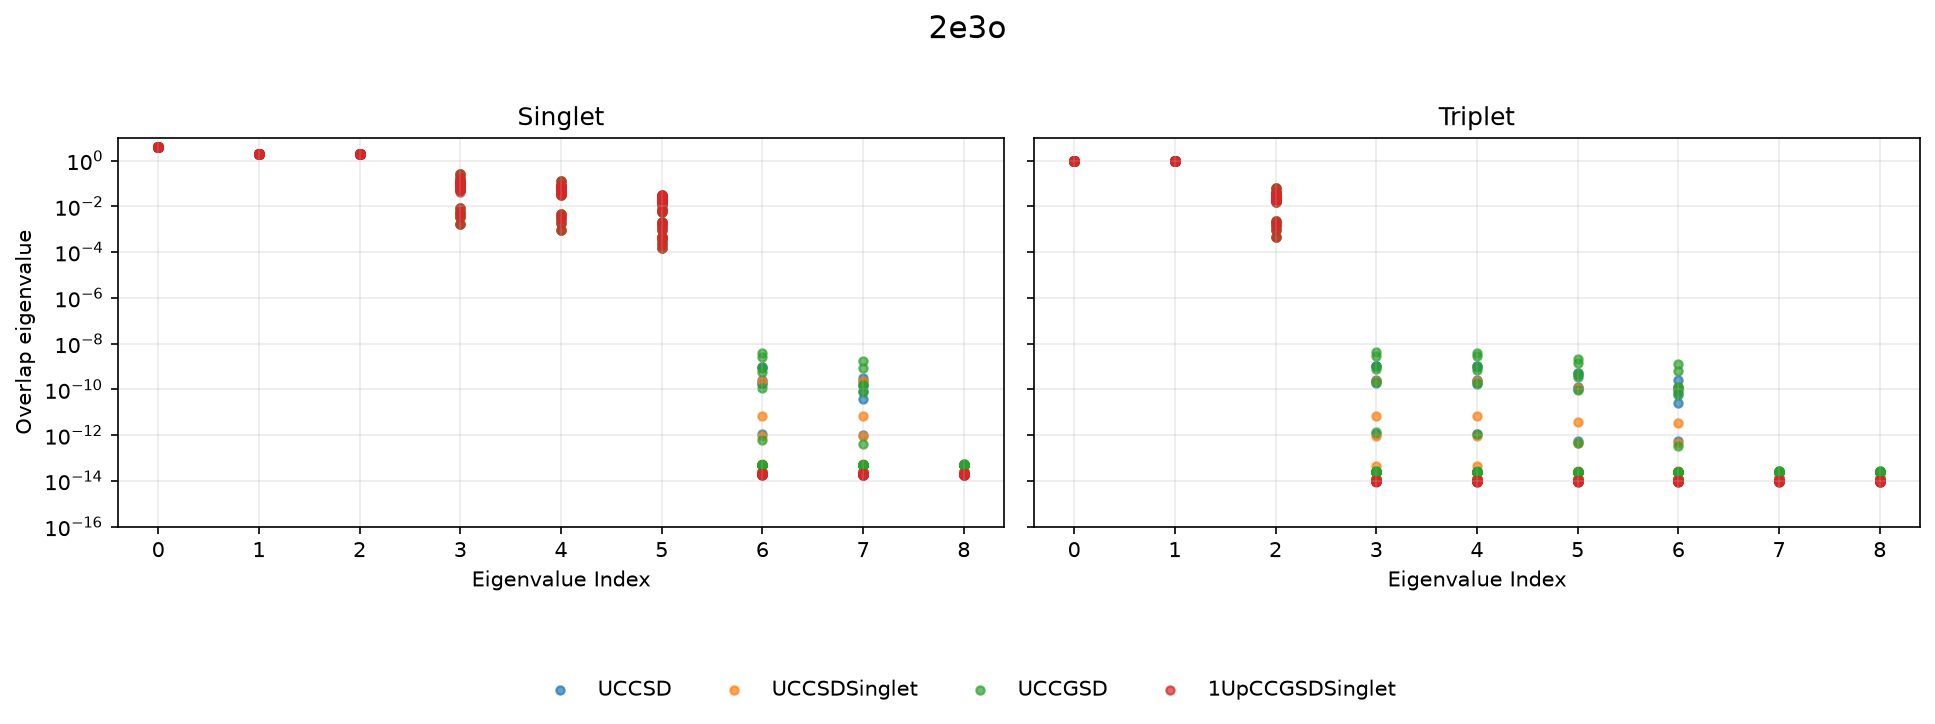
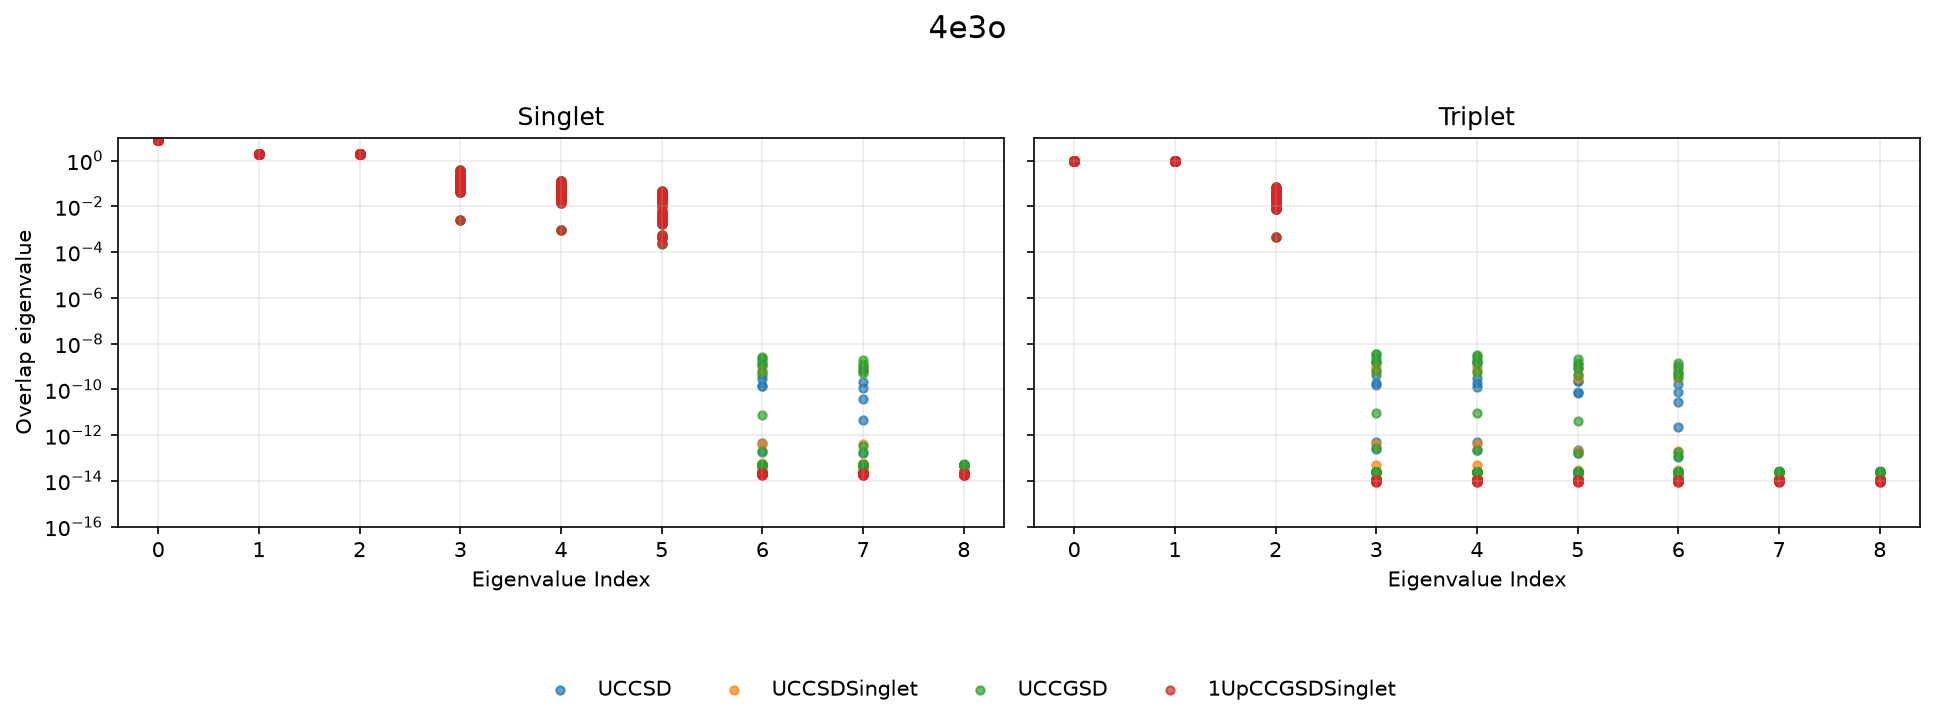
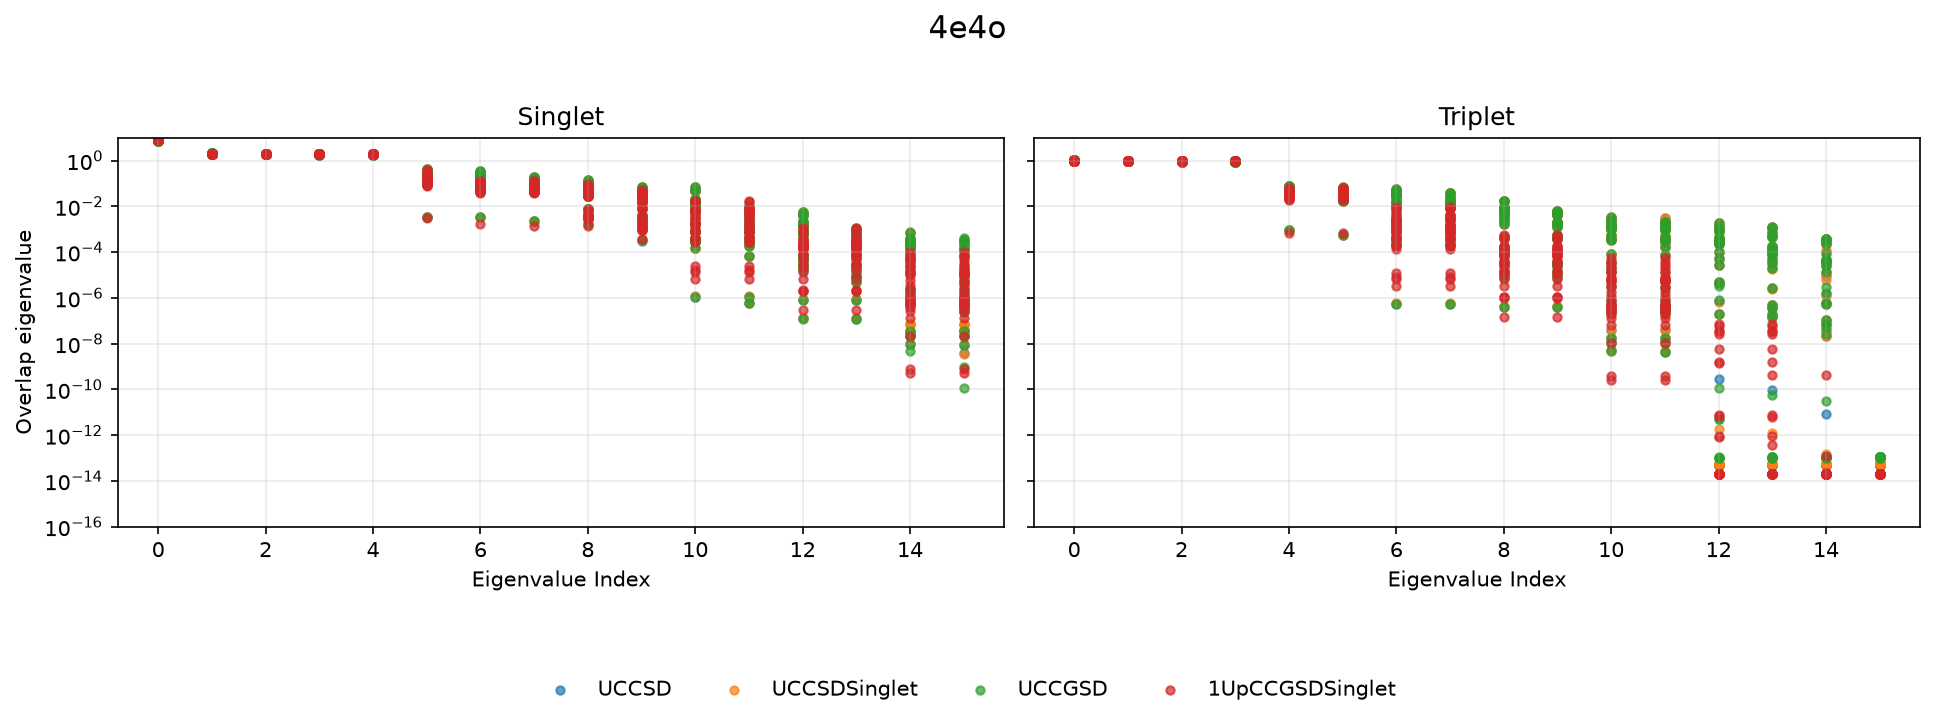
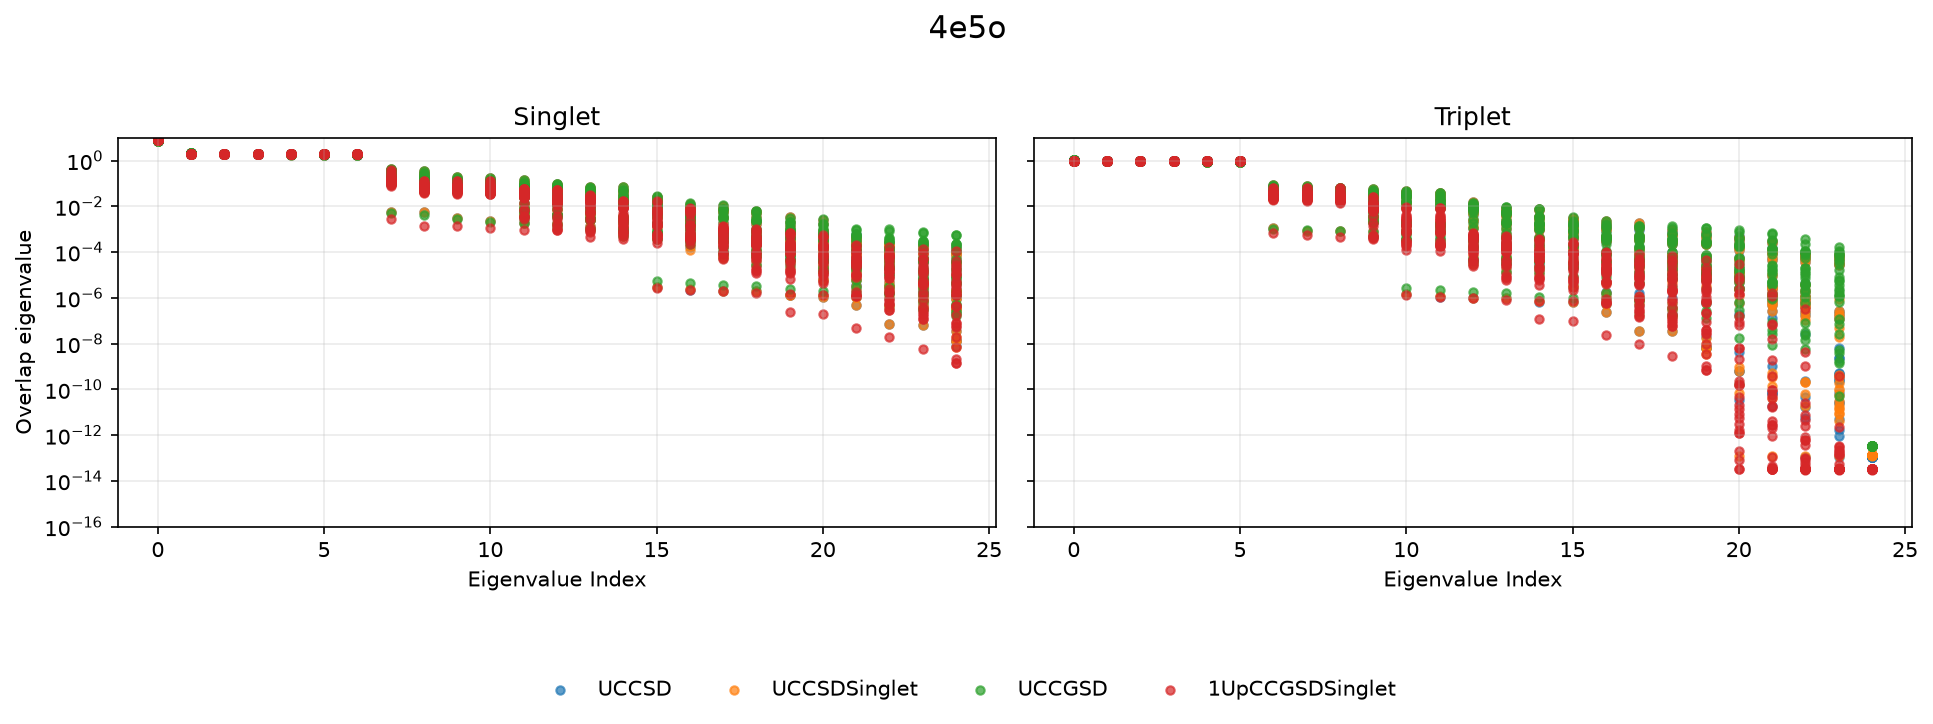
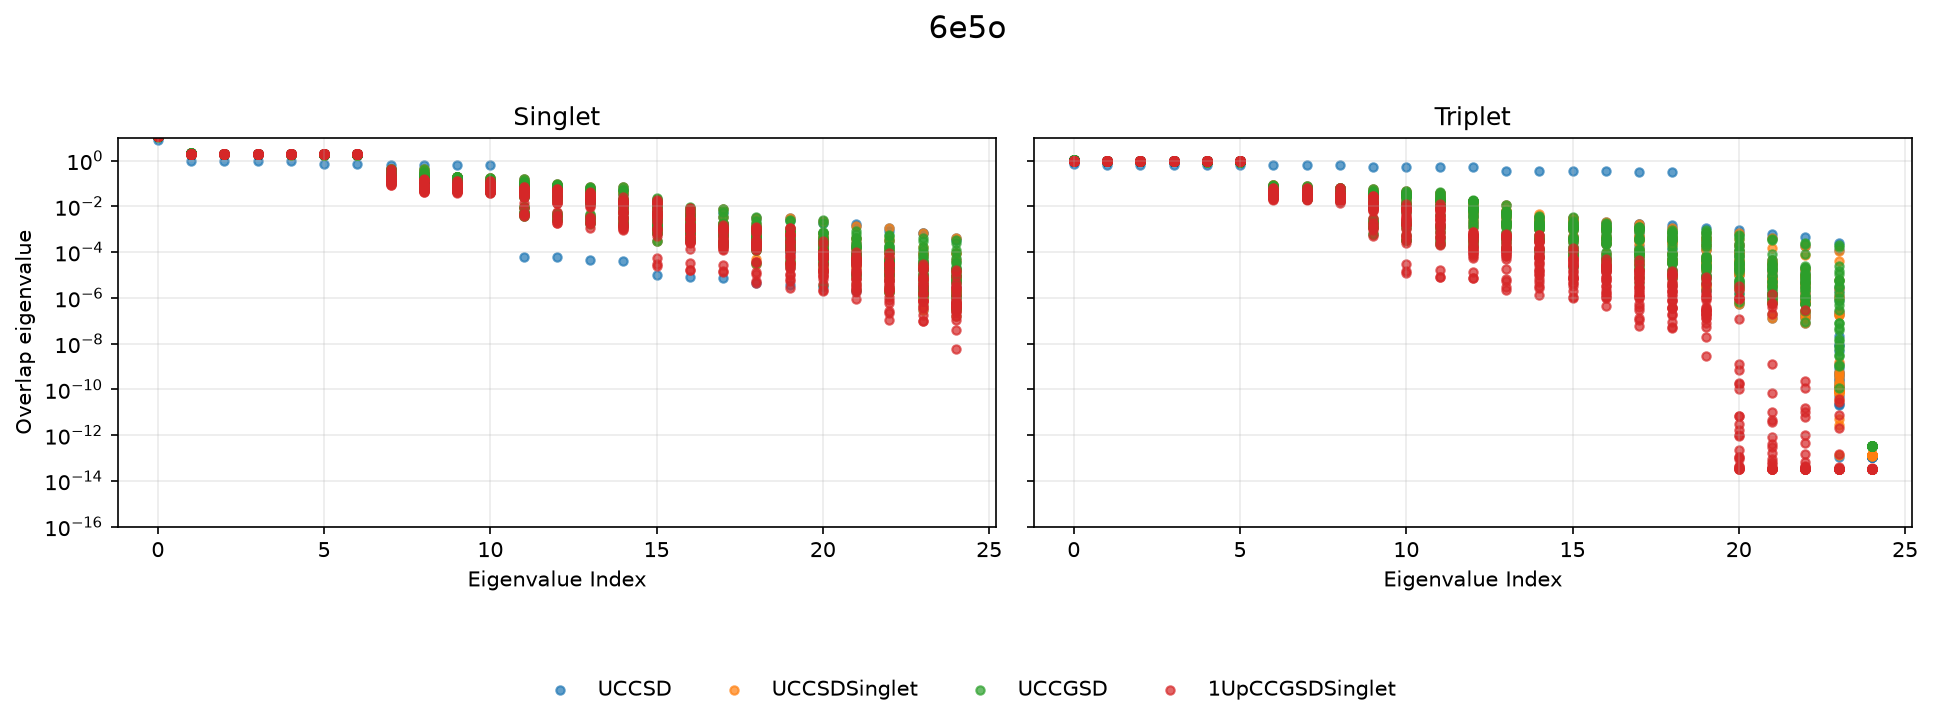
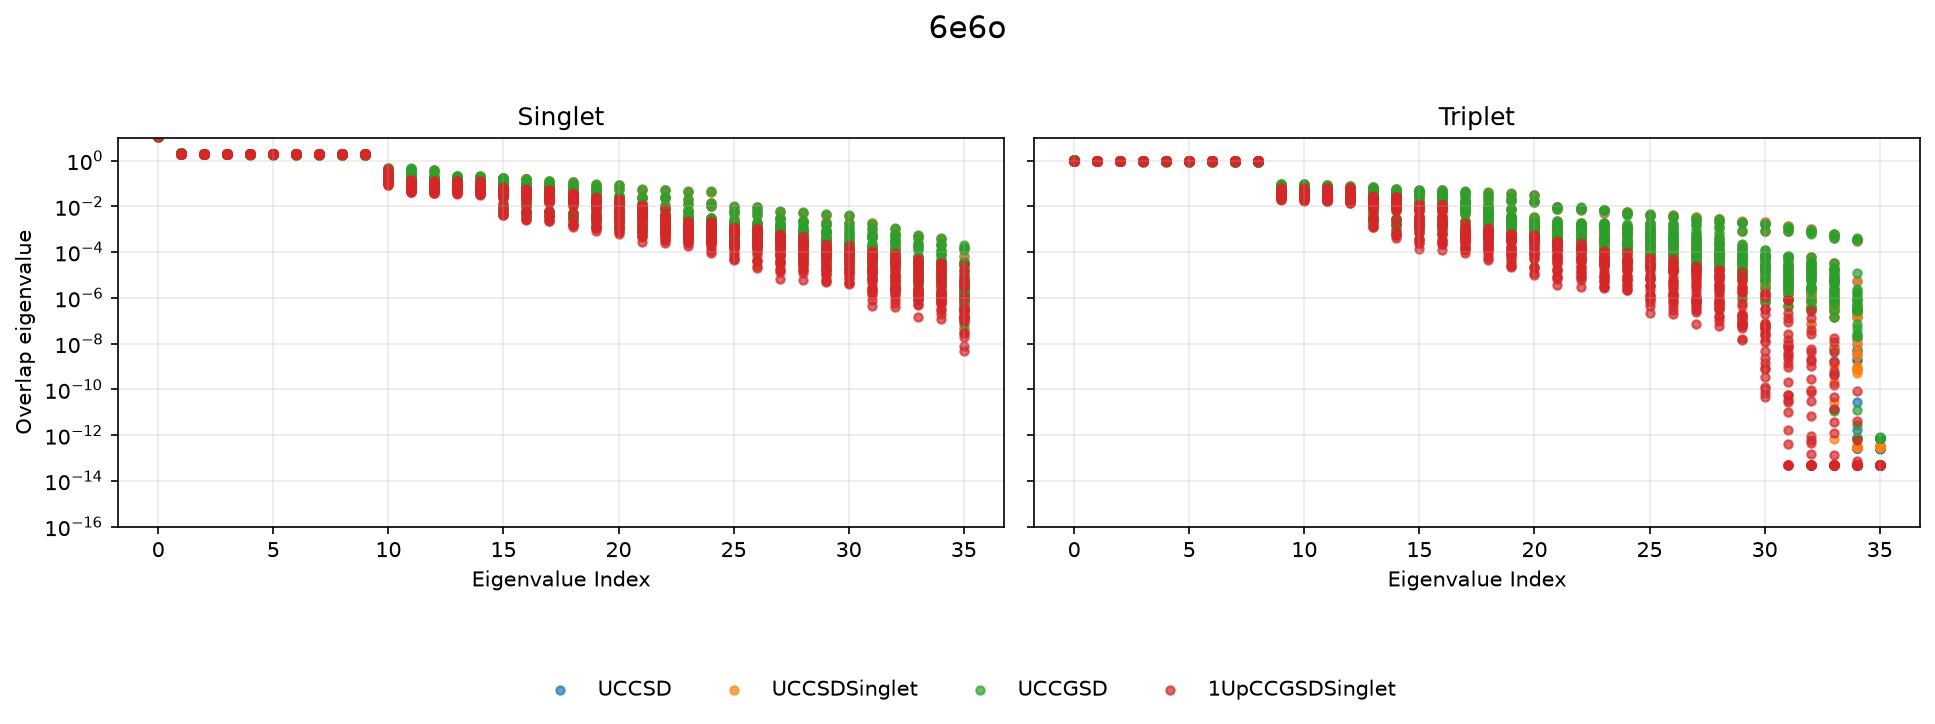

In [2]:
from notebook_utils.graphs import ANSATZ_ORDER, plot_spin_eigenvalue_spread, show_scrollable_figs


def overlap_eigenvalue_dict(df, active_space, expansion):
    data = {ansatz: [] for ansatz in ANSATZ_ORDER}
    rows = df[
        (df["active_space"] == active_space)
        & (df["expansion"] == expansion)
    ].copy()
    rows["ansatz"] = pd.Categorical(rows["ansatz"], categories=ANSATZ_ORDER, ordered=True)
    rows = rows.sort_values(["ansatz", "molecule"])

    for _, row in rows.iterrows():
        eigenvalues = np.sort(la.eigvalsh(np.asarray(row["S"], dtype=complex)).real)[::-1]
        points = [(index, eigenvalue) for index, eigenvalue in enumerate(eigenvalues)]

        data.setdefault(str(row["ansatz"]), []).extend(points)

    return {ansatz: points for ansatz, points in data.items() if points}


active_spaces = df_sv["active_space"].drop_duplicates().tolist()
eigenvalue_spreads = {}
figs = []

for active_space in active_spaces:
    singlet_data = overlap_eigenvalue_dict(df_sv, active_space, "singlet")
    triplet_data = overlap_eigenvalue_dict(df_sv, active_space, "triplet")

    eigenvalue_spreads[active_space] = {
        "singlet": singlet_data,
        "triplet": triplet_data,
    }

    fig, axes = plot_spin_eigenvalue_spread(
        singlet_data,
        triplet_data,
        title=active_space,
    )
    figs.append(fig)

show_scrollable_figs(figs)


## 2. Eigenvector Composition

Inspect the components of the overlap eigenvectors, especially those associated with the smallest and largest eigenvalues. This section should identify whether near-null directions are dominated by a small number of basis components or spread across the QSE excitation basis.


## 3. Supported-Subspace Filtering

Repeat the dimension analysis after ignoring tiny overlap eigenvectors and retaining only the fully supported subspace. This section should track retained rank, discarded directions, and the effect of the filtered subspace on the QSE energies.
